DATASET SHAPE
Rows: 1599
Columns: 12

FIRST 5 ROWS


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



DATA TYPES


,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64



MISSING VALUES


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



DESCRIPTIVE STATISTICS


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



ORIGINAL QUALITY DISTRIBUTION


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


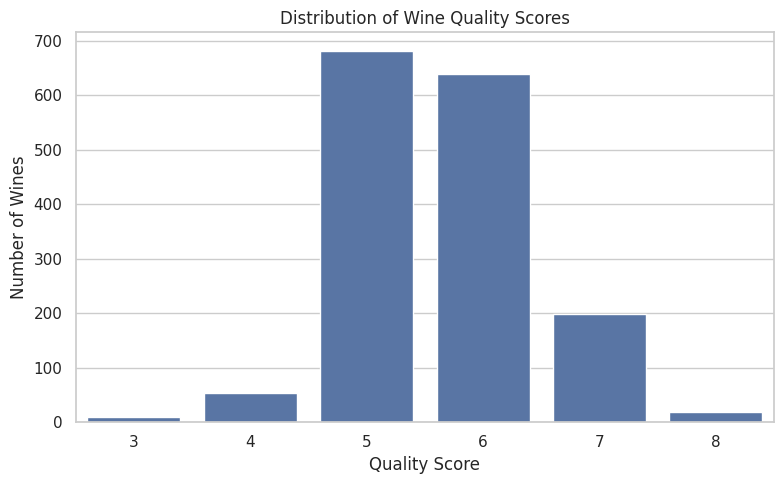

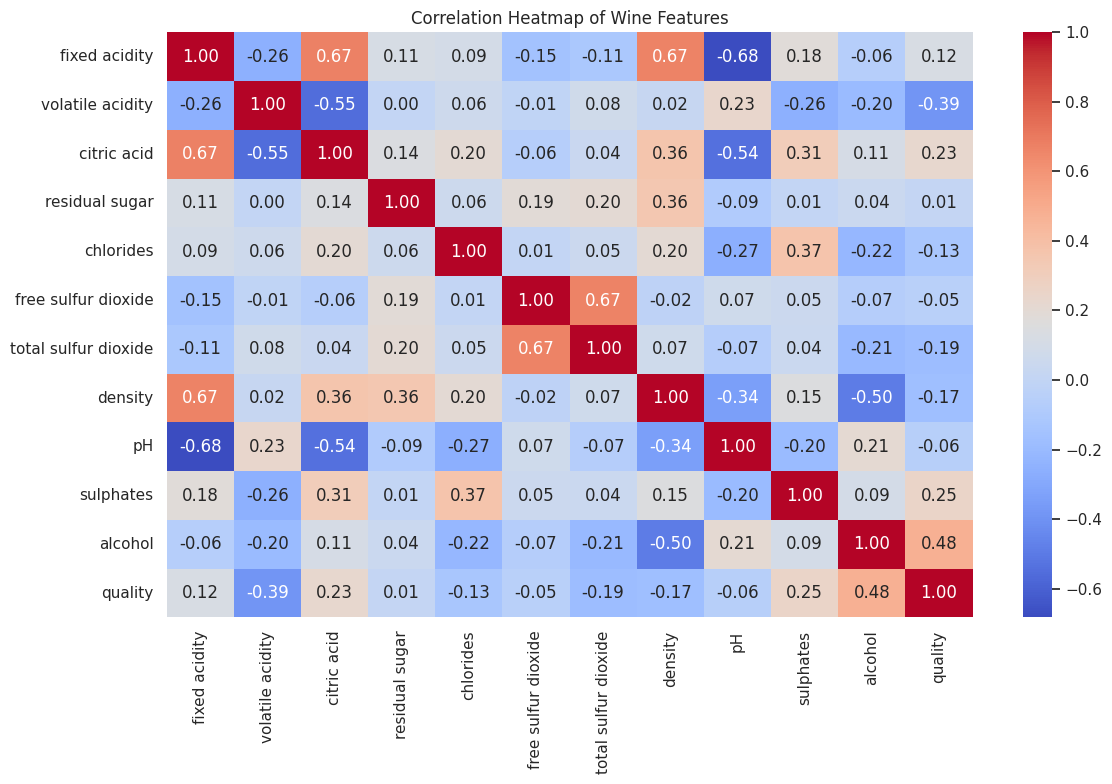

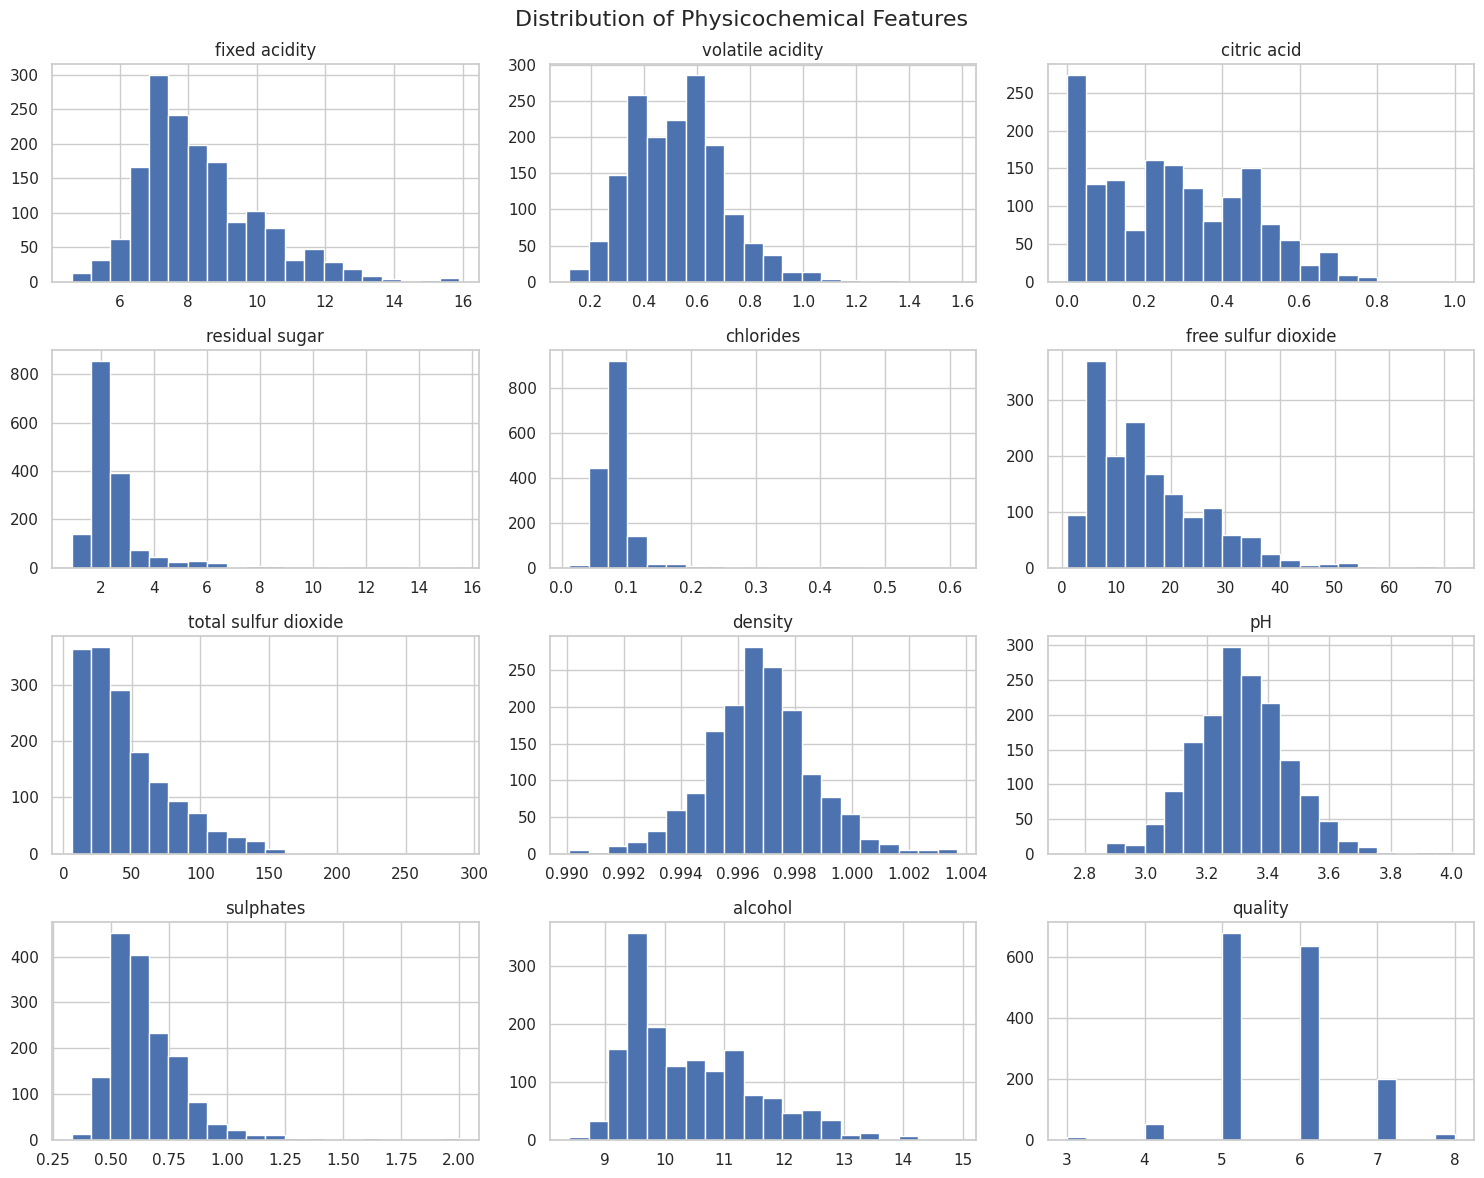


NEW QUALITY CLASS DISTRIBUTION
Low Quality: 744 (46.53%)
Medium Quality: 638 (39.90%)
High Quality: 217 (13.57%)

TRAINING DATA: (1279, 11)
TEST DATA: (320, 11)

================ RANDOM FOREST ================
Accuracy: 0.7406

Classification Report:
                precision    recall  f1-score   support

   Low Quality       0.79      0.81      0.80       149
Medium Quality       0.68      0.67      0.67       128
  High Quality       0.75      0.70      0.72        43

      accuracy                           0.74       320
     macro avg       0.74      0.73      0.73       320
  weighted avg       0.74      0.74      0.74       320


================ SGD CLASSIFIER ================
Accuracy: 0.5062

Classification Report:
                precision    recall  f1-score   support

   Low Quality       0.57      0.75      0.65       149
Medium Quality       0.37      0.16      0.23       128
  High Quality       0.43      0.67      0.52        43

      accuracy                      

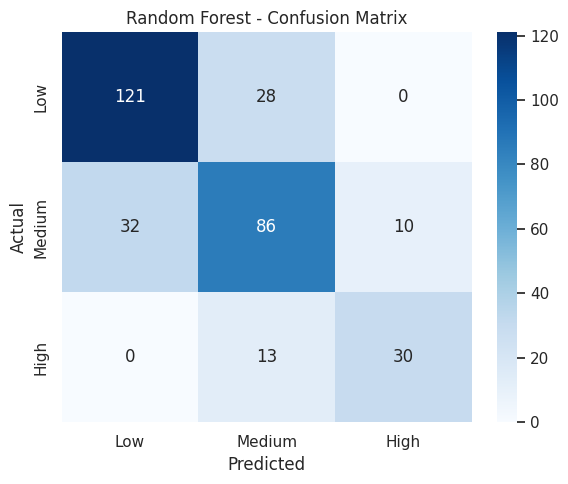

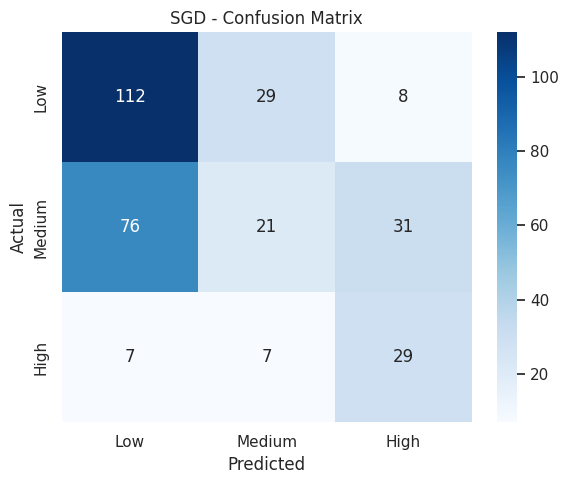

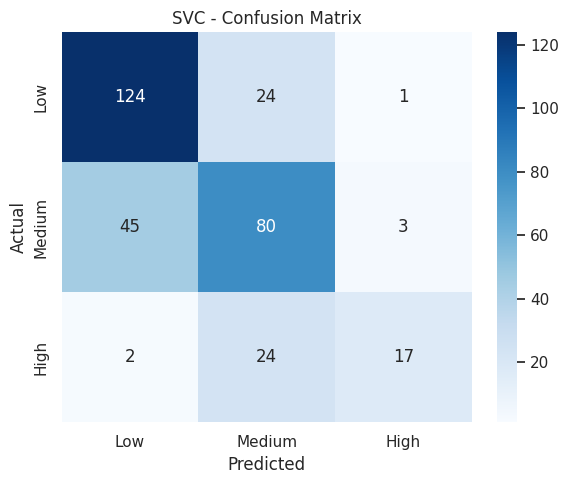


================ MODEL COMPARISON ================


,Model,Accuracy
0,Random Forest,0.7406
1,SGD,0.5062
2,SVC,0.6906



RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
10,alcohol,0.155232
9,sulphates,0.123409
1,volatile acidity,0.106379
6,total sulfur dioxide,0.097171
7,density,0.090294
4,chlorides,0.079534
2,citric acid,0.076691
8,pH,0.070817
0,fixed acidity,0.069910
3,residual sugar,0.067935


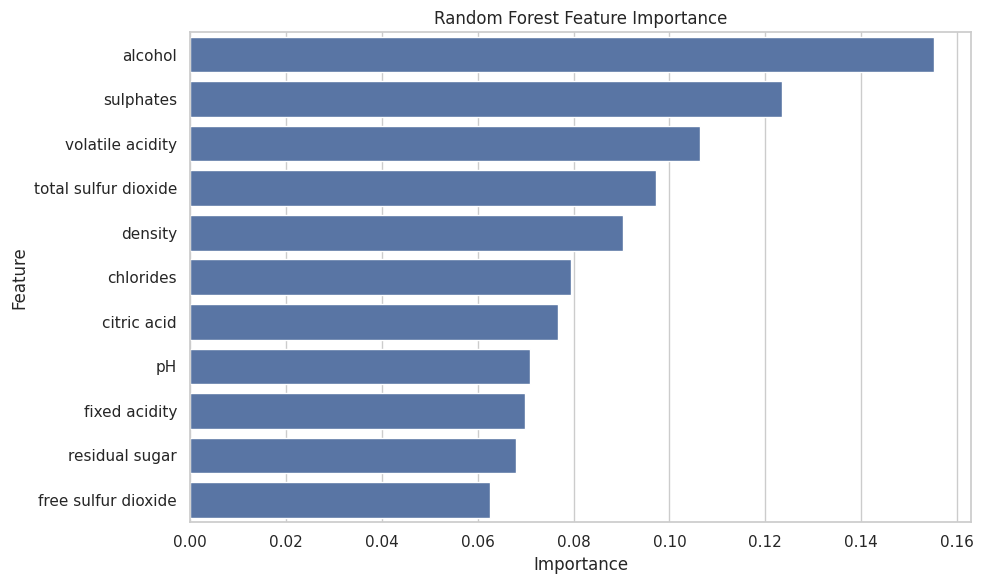


================ FINAL RESULT ================
Best performing model: Random Forest
Best accuracy: 0.7406

CONCLUSION

This project developed machine-learning models to classify
red wines into low, medium and high quality groups based on
their physicochemical properties.

Three classification algorithms were trained and compared:
Random Forest, Stochastic Gradient Descent (SGD), and Support
Vector Classifier (SVC).

The models were evaluated using accuracy, precision, recall,
F1-score and confusion matrices.

Random Forest feature importance was also analysed to identify
which chemical properties contributed most to prediction.

The best-performing model can be considered the most suitable
candidate for deployment, although additional validation and
hyperparameter tuning would be recommended before real-world
deployment.

The classification task is affected by class imbalance because
some quality scores occur more frequently than others. Therefore,
accuracy should be interpreted toget

In [2]:
# ============================================================
# OIBSIP - DATA ANALYTICS INTERNSHIP
# TASK 3: WINE QUALITY PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")


# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("winequality-red.csv", sep=";")

print("DATASET SHAPE")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFIRST 5 ROWS")
display(df.head())

print("\nDATA TYPES")
display(df.dtypes)

print("\nMISSING VALUES")
display(df.isnull().sum())


# ------------------------------------------------------------
# 2. DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

print("\nDESCRIPTIVE STATISTICS")
display(df.describe())


# ------------------------------------------------------------
# 3. QUALITY CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\nORIGINAL QUALITY DISTRIBUTION")
display(df["quality"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="quality")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Wine Features")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. FEATURE DISTRIBUTIONS
# ------------------------------------------------------------

df.hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Physicochemical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. FEATURE ENGINEERING
# ------------------------------------------------------------

# Convert wine quality into 3 classes:
# 0 = Low quality (3-5)
# 1 = Medium quality (6)
# 2 = High quality (7-8)

def quality_group(score):
    if score <= 5:
        return 0
    elif score == 6:
        return 1
    else:
        return 2


df["quality_group"] = df["quality"].apply(quality_group)

print("\nNEW QUALITY CLASS DISTRIBUTION")

quality_labels = {
    0: "Low Quality",
    1: "Medium Quality",
    2: "High Quality"
}

class_counts = df["quality_group"].value_counts().sort_index()

for class_id, count in class_counts.items():
    print(
        f"{quality_labels[class_id]}: {count} "
        f"({count / len(df) * 100:.2f}%)"
    )


# ------------------------------------------------------------
# 7. PREPARE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    columns=["quality", "quality_group"]
)

y = df["quality_group"]


# ------------------------------------------------------------
# 8. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTRAINING DATA:", X_train.shape)
print("TEST DATA:", X_test.shape)


# ------------------------------------------------------------
# 9. STANDARDISE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# 10. RANDOM FOREST CLASSIFIER
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("\n================ RANDOM FOREST ================")
print(f"Accuracy: {rf_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Low Quality",
            "Medium Quality",
            "High Quality"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 11. SGD CLASSIFIER
# ------------------------------------------------------------

sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(
    X_train_scaled,
    y_train
)

sgd_predictions = sgd_model.predict(
    X_test_scaled
)

sgd_accuracy = accuracy_score(
    y_test,
    sgd_predictions
)

print("\n================ SGD CLASSIFIER ================")
print(f"Accuracy: {sgd_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        sgd_predictions,
        target_names=[
            "Low Quality",
            "Medium Quality",
            "High Quality"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 12. SUPPORT VECTOR CLASSIFIER
# ------------------------------------------------------------

svc_model = SVC(
    kernel="rbf",
    random_state=42
)

svc_model.fit(
    X_train_scaled,
    y_train
)

svc_predictions = svc_model.predict(
    X_test_scaled
)

svc_accuracy = accuracy_score(
    y_test,
    svc_predictions
)

print("\n================ SUPPORT VECTOR CLASSIFIER ================")
print(f"Accuracy: {svc_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svc_predictions,
        target_names=[
            "Low Quality",
            "Medium Quality",
            "High Quality"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 13. CONFUSION MATRICES
# ------------------------------------------------------------

models_predictions = {
    "Random Forest": rf_predictions,
    "SGD": sgd_predictions,
    "SVC": svc_predictions
}

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Low",
            "Medium",
            "High"
        ],
        yticklabels=[
            "Low",
            "Medium",
            "High"
        ]
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 14. MODEL COMPARISON
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD",
        "SVC"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

print("\n================ MODEL COMPARISON ================")
display(comparison)


# ------------------------------------------------------------
# 15. FEATURE IMPORTANCE - RANDOM FOREST
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("\nRANDOM FOREST FEATURE IMPORTANCE")
display(feature_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. BEST MODEL
# ------------------------------------------------------------

best_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = comparison["Accuracy"].max()

print("\n================ FINAL RESULT ================")

print(
    f"Best performing model: {best_model}"
)

print(
    f"Best accuracy: {best_accuracy:.4f}"
)


# ------------------------------------------------------------
# 17. CONCLUSION
# ------------------------------------------------------------

print("""
============================================================
CONCLUSION
============================================================

This project developed machine-learning models to classify
red wines into low, medium and high quality groups based on
their physicochemical properties.

Three classification algorithms were trained and compared:
Random Forest, Stochastic Gradient Descent (SGD), and Support
Vector Classifier (SVC).

The models were evaluated using accuracy, precision, recall,
F1-score and confusion matrices.

Random Forest feature importance was also analysed to identify
which chemical properties contributed most to prediction.

The best-performing model can be considered the most suitable
candidate for deployment, although additional validation and
hyperparameter tuning would be recommended before real-world
deployment.

The classification task is affected by class imbalance because
some quality scores occur more frequently than others. Therefore,
accuracy should be interpreted together with precision, recall
and F1-score.
""")

print("\nTASK 3 COMPLETED SUCCESSFULLY!")